# Chapter 2 Exercises

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.sampling_bars import dollar_bar, dollar_imbalance_bar

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

In [2]:
dollar_bars = dollar_bar(df)

In [3]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol
date,,,,,
2009-09-28 09:32:06,50.7800,50.76,50.78,500,25390.0000
2009-09-28 09:33:54,50.8200,50.80,50.82,100,5082.0000
2009-09-28 09:37:33,50.8299,50.80,50.83,166,8437.7634
2009-09-28 09:41:53,50.8400,50.83,50.84,200,10168.0000
2009-09-28 09:44:09,50.9100,50.91,50.92,1100,56001.0000


In [4]:
dollar_bars.shape

(903958, 5)

## 4. Form E-mini S&P 500 futures dollar bars:

### a. Compute Bollinger bands of width 5% around a rolling moving average. Count how many times prices cross the bands out (from within the bands to outside the bands).

In [5]:
MA = dollar_bars['price'].rolling(50000).mean()

upper_band = MA * 1.05
lower_band = MA * 0.95

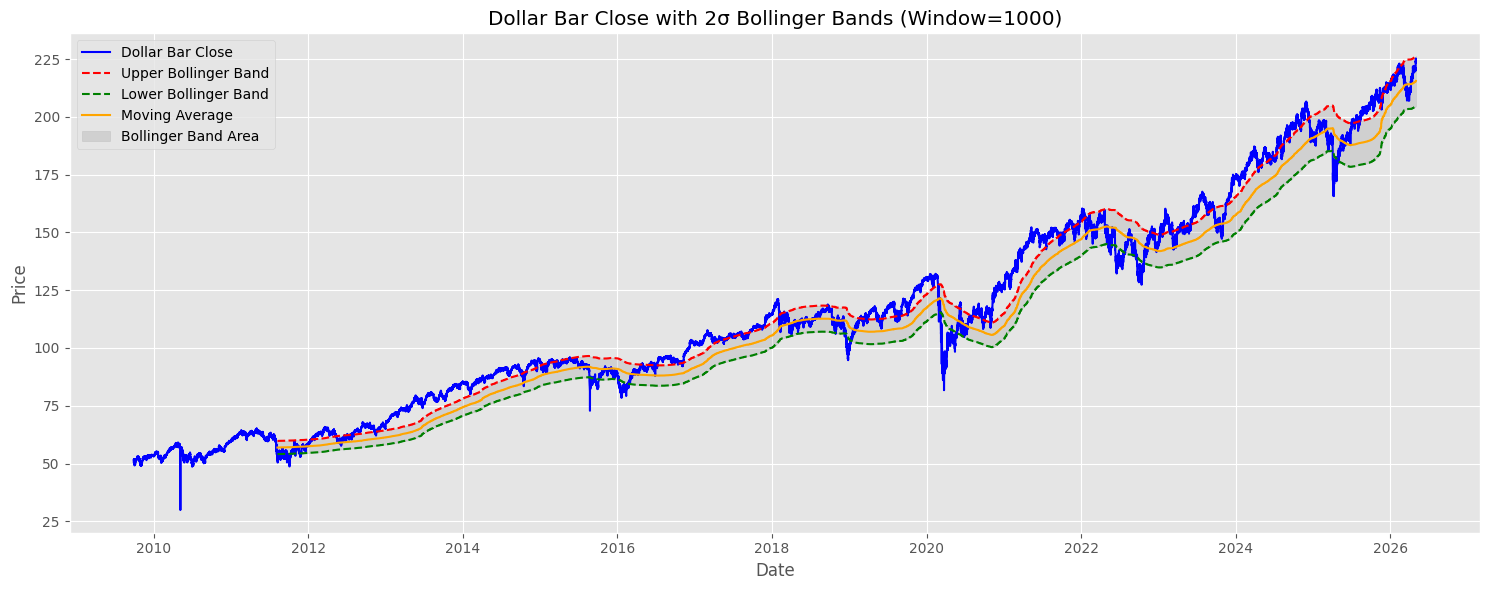

Crosses up & out: 945
Crosses down & out: 260


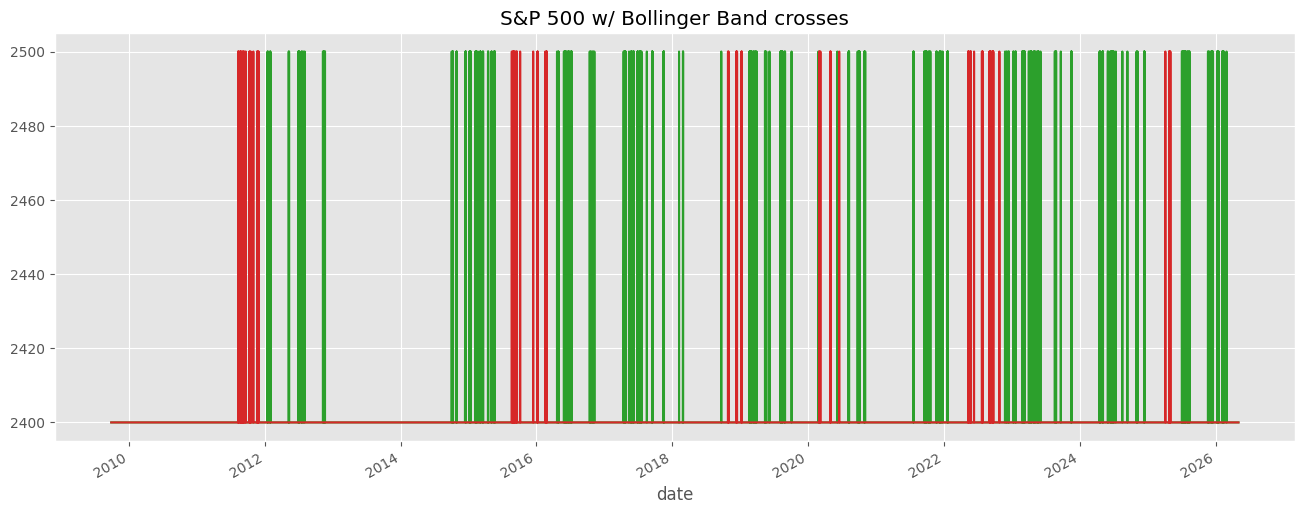

In [6]:
plt.figure(figsize=(15,6))
plt.plot(dollar_bars.index, dollar_bars['price'], label='Dollar Bar Close', color='blue')
plt.plot(dollar_bars.index, upper_band, label='Upper Bollinger Band', color='red', linestyle='--')
plt.plot(dollar_bars.index, lower_band, label='Lower Bollinger Band', color='green', linestyle='--')
plt.plot(dollar_bars.index, MA, label='Moving Average', color='orange', linestyle='-')

plt.fill_between(dollar_bars.index, lower_band, upper_band, color='grey', alpha=0.2, label='Bollinger Band Area')

plt.title('Dollar Bar Close with 2σ Bollinger Bands (Window=1000)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Calculate band crosses as requested
close = dollar_bars['price']
prev_inside = close.shift(1).between(lower_band.shift(1), upper_band.shift(1))
crosses_up = prev_inside & (close > upper_band)
crosses_down = prev_inside & (close < lower_band)

print("Crosses up & out:", crosses_up.sum())
print("Crosses down & out:", crosses_down.sum())

# Plot the locations of crosses, use secondary plots to highlight these points above the price area
(crosses_up.astype(float) * 100 + 2400).plot(color='tab:green')
(crosses_down.astype(float) * 100 + 2400).plot(color='tab:red', title='S&P 500 w/ Bollinger Band crosses');

### b. Now sample those bars using a CUSUM filter, where {yt} are returns and  h = 0.05. How many samples do you get?

In [7]:
# Sample the dollar bars using a CUSUM filter on signed returns.

def cusum_filter(series, threshold):
    """Return integer positions where the signed CUSUM exceeds +/- threshold."""
    s_pos, s_neg = 0, 0
    event_positions = []

    for position, value in enumerate(series):
        if pd.isna(value):
            continue

        s_pos = max(0, s_pos + value)
        s_neg = min(0, s_neg + value)

        if s_pos > threshold:
            event_positions.append(position)
            s_pos = 0
        elif s_neg < -threshold:
            event_positions.append(position)
            s_neg = 0

    return event_positions


dollar_bars = dollar_bars.copy()
dollar_bars['returns'] = dollar_bars['price'].pct_change()
returns = dollar_bars['returns']

threshold = 0.05
signed_sampled_positions = cusum_filter(returns, threshold)
signed_sampled_bars = dollar_bars.iloc[signed_sampled_positions].copy()
signed_sampled_indices = signed_sampled_bars.index

# Keep these names for the exercise-4 rolling-standard-deviation cell below.
sampled_positions = signed_sampled_positions
sampled_indices = signed_sampled_indices
sampled_bars = signed_sampled_bars

is_signed_sample = np.zeros(len(dollar_bars), dtype=bool)
is_signed_sample[signed_sampled_positions] = True
dollar_bars['is_signed_cusum_sample'] = is_signed_sample

print(f"Number of signed-return CUSUM samples: {len(signed_sampled_bars)}")

Number of signed-return CUSUM samples: 343


### c. Compute the rolling standard deviation of the two-sampled series. Which one is least heteroscedastic? What is the reason for these results?

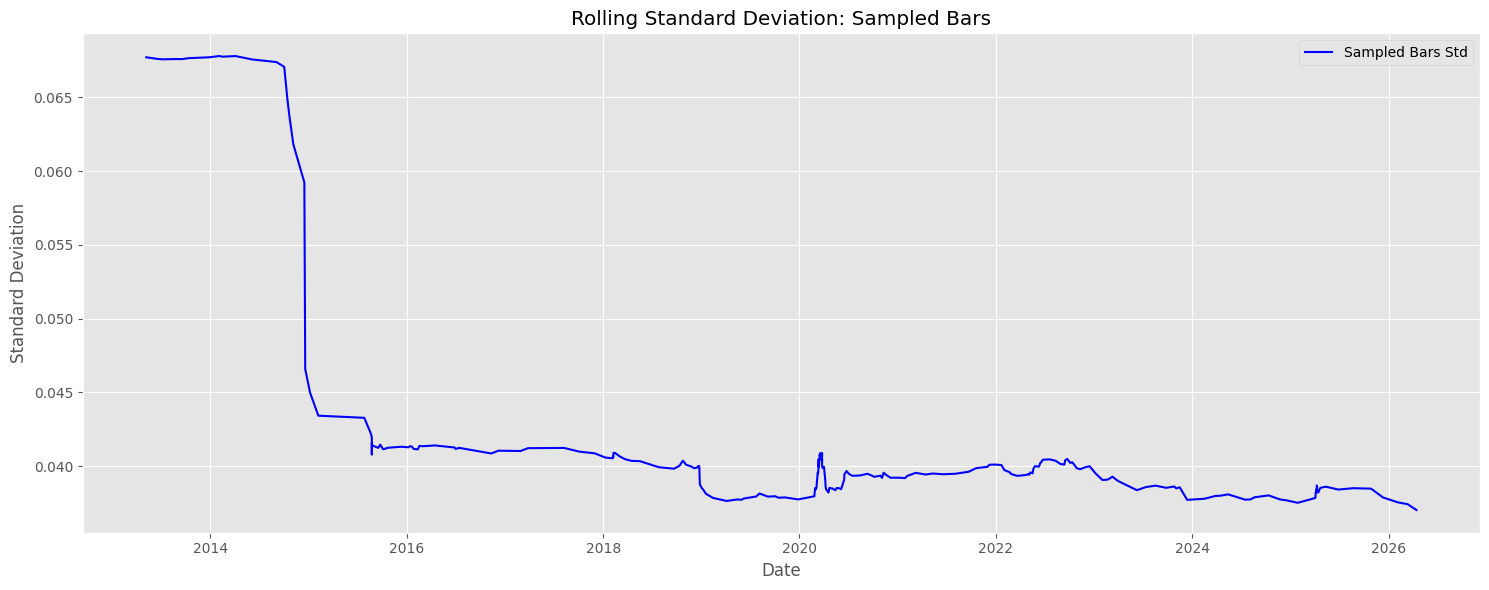

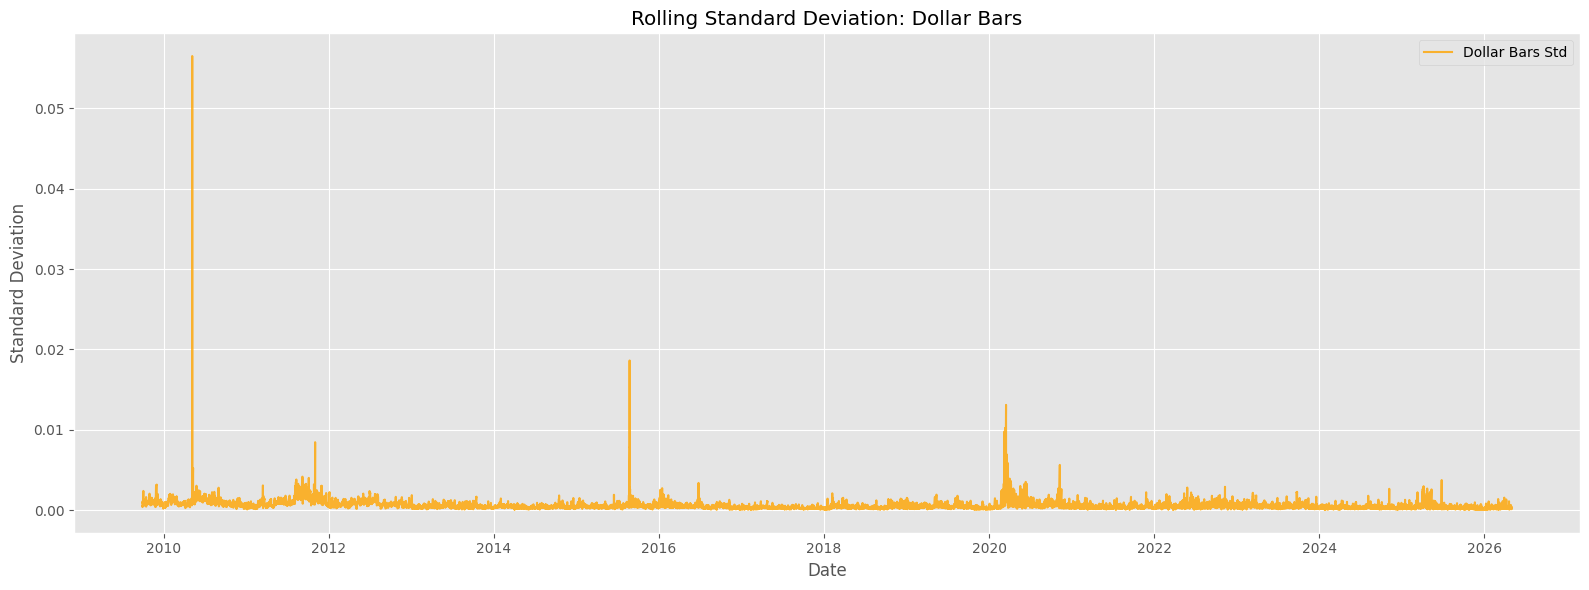

In [8]:
# Compute the rolling standard deviation of the two-sampled series and dollar bars
sampled_bars['returns'] = sampled_bars['price'].pct_change()
sampled_bars['std'] = sampled_bars['returns'].rolling(window=100).std()

dollar_bars['returns'] = dollar_bars['price'].pct_change()
dollar_bars['std'] = dollar_bars['returns'].rolling(window=100).std()

# Plot the rolling standard deviation for sampled bars
plt.figure(figsize=(15,6))
plt.plot(sampled_bars.index, sampled_bars['std'], label='Sampled Bars Std', color='blue')
plt.title('Rolling Standard Deviation: Sampled Bars')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()
plt.tight_layout()
plt.show()

# Plot the rolling standard deviation for dollar bars
plt.figure(figsize=(16,6))
plt.plot(dollar_bars.index, dollar_bars['std'], label='Dollar Bars Std', color='orange', alpha=0.8)
plt.title('Rolling Standard Deviation: Dollar Bars')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Using the bars from exercise 4:

### a. Sample bars using the CUSUM filter, where {yt} are absolute returns and  h = 0.05.

In [9]:
# Sample the dollar bars using a CUSUM filter on absolute returns.
# This samples accumulated volatility rather than signed directional moves.

dollar_bars['abs_returns'] = dollar_bars['returns'].abs()
abs_returns = dollar_bars['abs_returns']

abs_sampled_positions = cusum_filter(abs_returns, threshold)
abs_sampled_bars = dollar_bars.iloc[abs_sampled_positions].copy()
abs_sampled_indices = abs_sampled_bars.index

is_abs_sample = np.zeros(len(dollar_bars), dtype=bool)
is_abs_sample[abs_sampled_positions] = True
dollar_bars['is_abs_cusum_sample'] = is_abs_sample

print(f"Number of absolute-return CUSUM samples: {len(abs_sampled_bars)}")
print("Same positions as signed-return CUSUM:", abs_sampled_positions == signed_sampled_positions)

Number of absolute-return CUSUM samples: 6039
Same positions as signed-return CUSUM: False


### b. Compute the rolling standard deviation of the sampled bars.

### c. Compare this result with the results from exercise 4. What procedure delivered the least heteroscedastic sample? Why?

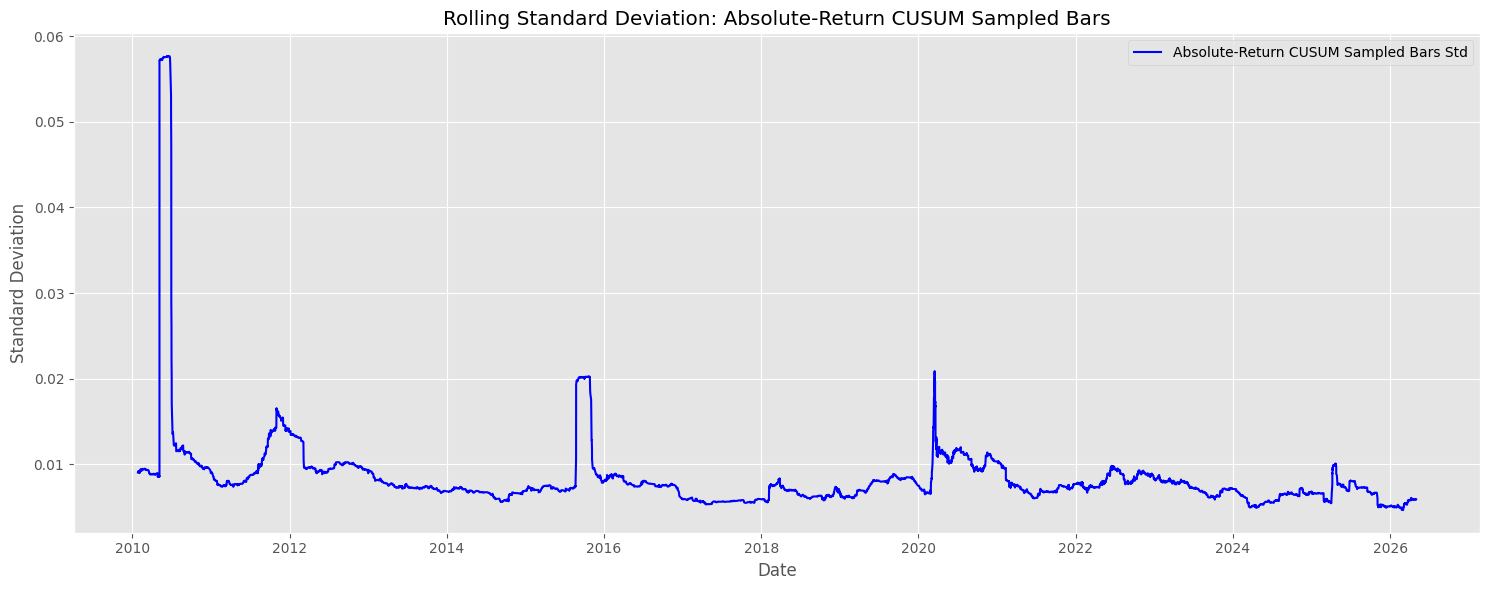

In [10]:
# Compute the rolling standard deviation of the absolute-return CUSUM sampled bars.
abs_sampled_bars['returns'] = abs_sampled_bars['price'].pct_change()
abs_sampled_bars['std'] = abs_sampled_bars['returns'].rolling(window=100).std()

plt.figure(figsize=(15,6))
plt.plot(
    abs_sampled_bars.index,
    abs_sampled_bars['std'],
    label='Absolute-Return CUSUM Sampled Bars Std',
    color='blue',
)
plt.title('Rolling Standard Deviation: Absolute-Return CUSUM Sampled Bars')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()
plt.tight_layout()
plt.show()
